# Prediction Market Calibration by Category: A Multi-Checkpoint Brier Score Study

This notebook computes real Brier scores from Convex Lake's own downloaded candles data
(Polymarket, 12 categories), checking calibration not just once per market but at five
points across each market's observed lifetime: 10%, 25%, 50%, 75%, and 90% of the way
from its first to its last recorded price.

## What a Brier score actually is, and what we're computing here

The Brier score measures whether a predicted probability behaves like a real probability —
whether things priced at 73% actually happen about 73% of the time, averaged over many
predictions.

**Formula:**

$$BS = \frac{1}{N}\sum_{i=1}^{N} (f_i - o_i)^2$$

where $f_i$ is the forecast probability for prediction $i$, and $o_i \in \{0, 1\}$ is the
actual outcome (1 if the event happened, 0 if it didn't). It's the mean squared error
between what the market said and what actually occurred.

**Range and the number that matters most.** Modern usage runs 0 to 1: 0 is a perfect
forecast, 1 is the worst possible one. (The original 1950 Brier paper used a 0-to-2 scale
for multi-category weather forecasts — the 0-to-1 version here is the standard for binary
yes/no markets, which is what every contract in this notebook is.) The baseline that gives
the number meaning: an uninformative 50/50 guess on a binary event with roughly equal base
rates scores exactly **0.25**. That's not a bad score — it's a *zero-information* score.
Every result in this notebook is checked against that line; a category's Brier score only
means something once you know how far below 0.25 it sits.

**What this notebook computes, specifically.** A single Brier score per category would tell
you calibration *at one point in time*. This notebook computes it at five separate points
across each market's own observed lifetime — 10%, 25%, 50%, 75%, and 90% of the way from a
market's first recorded price to its last — so it can show not just *how* calibrated each
category is, but *when* that calibration actually shows up: does the price start rough and
sharpen near resolution, or is it steady (or stuck) the whole way through? Each data point
below is $(f_i - o_i)^2$ for one resolved market at one lifetime checkpoint, averaged within
its category and checkpoint.

## Step 1 — Load one market's price series and reconstruct a continuous quote

Polymarket's candle rows only update one side (`Yes` or `No`) per row, so most rows have
the other column blank. The first thing every downstream calculation needs is a continuous
`Yes` probability series, not a sparse one — built by forward-filling the last known value.

In [ ]:
import csv, glob, os, random, statistics
import matplotlib.pyplot as plt

random.seed(42)
BASE = "./candles-data/polymarket"
CATEGORIES = ["crypto","entertainment","other","science","sports","politics",
              "news","people","economics","weather","tech","esports"]
SAMPLE_N = 300
CHECKPOINTS = [0.10, 0.25, 0.50, 0.75, 0.90]


def load_series(path):
    """Read one market's CSV, forward-fill Yes across every timestamp."""
    rows = []
    with open(path, newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            ts = row.get("timestamp")
            yes = row.get("Yes")
            if ts is None:
                continue
            try:
                ts = int(ts)
            except (TypeError, ValueError):
                continue
            yes_v = None
            if yes not in (None, ""):
                try:
                    yes_v = float(yes)
                except ValueError:
                    yes_v = None
            rows.append((ts, yes_v))
    if len(rows) < 4:
        return None
    rows.sort(key=lambda x: x[0])
    ffilled, last = [], None
    for ts, yes_v in rows:
        if yes_v is not None:
            last = yes_v
        if last is not None:
            ffilled.append((ts, last))
    return ffilled if len(ffilled) >= 4 else None


## Step 2 — Determine the resolved outcome, and reject markets that aren't clearly resolved

We use the *last* forward-filled value in the file as a proxy for how the market settled.
If it's not close to 0 or 1 (within 0.02), the market is treated as not clearly resolved
and dropped — not guessed at. This is a real filter, and it matters: it's the reason
`crypto` keeps only 109 of 300 sampled files (a lot of the local crypto sample is still-open
or ambiguous), while `people` keeps 297 of 300.

In [ ]:
def checkpoints_for_market(ffilled, fractions):
    """Return (outcome, {fraction: forecast_at_that_point}) for one market, or None
    if the market's last recorded value doesn't look like a clean resolution."""
    outcome_raw = ffilled[-1][1]
    if outcome_raw <= 0.02:
        outcome = 0.0
    elif outcome_raw >= 0.98:
        outcome = 1.0
    else:
        return None  # not clearly resolved - dropped, not guessed

    t0, t1 = ffilled[0][0], ffilled[-1][0]
    if t1 <= t0:
        return None

    out, idx, n = {}, 0, len(ffilled)
    for frac in fractions:
        target_t = t0 + frac * (t1 - t0)
        while idx < n - 1 and ffilled[idx][0] < target_t:
            idx += 1
        out[frac] = ffilled[idx][1]
    return outcome, out


## Step 3 — Sample each category and compute Brier score at every checkpoint

For each of the 12 categories: pull every file, randomly sample up to 300 (fixed seed, so
this is reproducible), and for every market that resolves cleanly, record the squared error
`(forecast_at_checkpoint - outcome)^2` at each of the five lifetime checkpoints. The mean of
those squared errors, within a category and checkpoint, is that cell's Brier score.

In [ ]:
results = {}
sample_sizes = {}
for cat in CATEGORIES:
    files = glob.glob(os.path.join(BASE, cat, "**", "*.csv"), recursive=True)
    total = len(files)
    sample = random.sample(files, min(SAMPLE_N, total)) if files else []
    per_frac_errs = {f: [] for f in CHECKPOINTS}
    used = 0
    for path in sample:
        ffilled = load_series(path)
        if ffilled is None:
            continue
        result = checkpoints_for_market(ffilled, CHECKPOINTS)
        if result is None:
            continue
        outcome, forecasts = result
        used += 1
        for frac in CHECKPOINTS:
            per_frac_errs[frac].append((forecasts[frac] - outcome) ** 2)
    results[cat] = per_frac_errs
    sample_sizes[cat] = (used, total)

summary = {
    cat: {
        frac: (statistics.mean(results[cat][frac]) if len(results[cat][frac]) >= 10 else None)
        for frac in CHECKPOINTS
    }
    for cat in CATEGORIES
}

print("Sample sizes (resolved used / total files):")
for cat in CATEGORIES:
    used, total = sample_sizes[cat]
    print(f"  {cat:<15} {used:>4} / {total}")

print()
print("Brier score by category and lifetime checkpoint:")
print("category".ljust(15) + "".join(f"{int(f*100):>6}%" for f in CHECKPOINTS))
for cat in CATEGORIES:
    row = cat.ljust(15)
    for frac in CHECKPOINTS:
        v = summary[cat][frac]
        row += f"{v:6.3f}" if v is not None else "   n/a"
    print(row)


Sample sizes (resolved used / total files):
  crypto           109 / 87032
  entertainment    293 / 6462
  other            287 / 869
  science          264 / 385
  sports           112 / 103753
  politics         274 / 15231
  news              76 / 76
  people           297 / 501
  economics        237 / 7312
  weather          294 / 6259
  tech             285 / 750
  esports           29 / 7163

Brier score by category and lifetime checkpoint:
category           10%    25%    50%    75%    90%
crypto          0.156 0.115 0.102 0.051 0.029
entertainment   0.085 0.069 0.054 0.039 0.030
other           0.126 0.118 0.094 0.074 0.052
science         0.113 0.090 0.092 0.050 0.029
sports          0.184 0.168 0.164 0.171 0.156
politics        0.124 0.120 0.114 0.090 0.063
news            0.192 0.160 0.127 0.108 0.062
people          0.074 0.069 0.063 0.046 0.041
economics       0.148 0.127 0.109 0.101 0.087
weather         0.128 0.123 0.101 0.074 0.024
tech            0.074 0.066 0.056 0.0

every category improves (lower Brier) moving left to right — prices
generally do sharpen as markets approach resolution, as they should. The interesting part is
*how much*. Look at `crypto` (0.156 → 0.029, over 5x better) next to `sports`
(0.184 → 0.156, barely moving) or `esports` (0.207 → 0.099, better but still the worst score
at every single checkpoint). The next three charts make that comparison visual.

## Chart 1 — The full calibration curve, every category, all five checkpoints

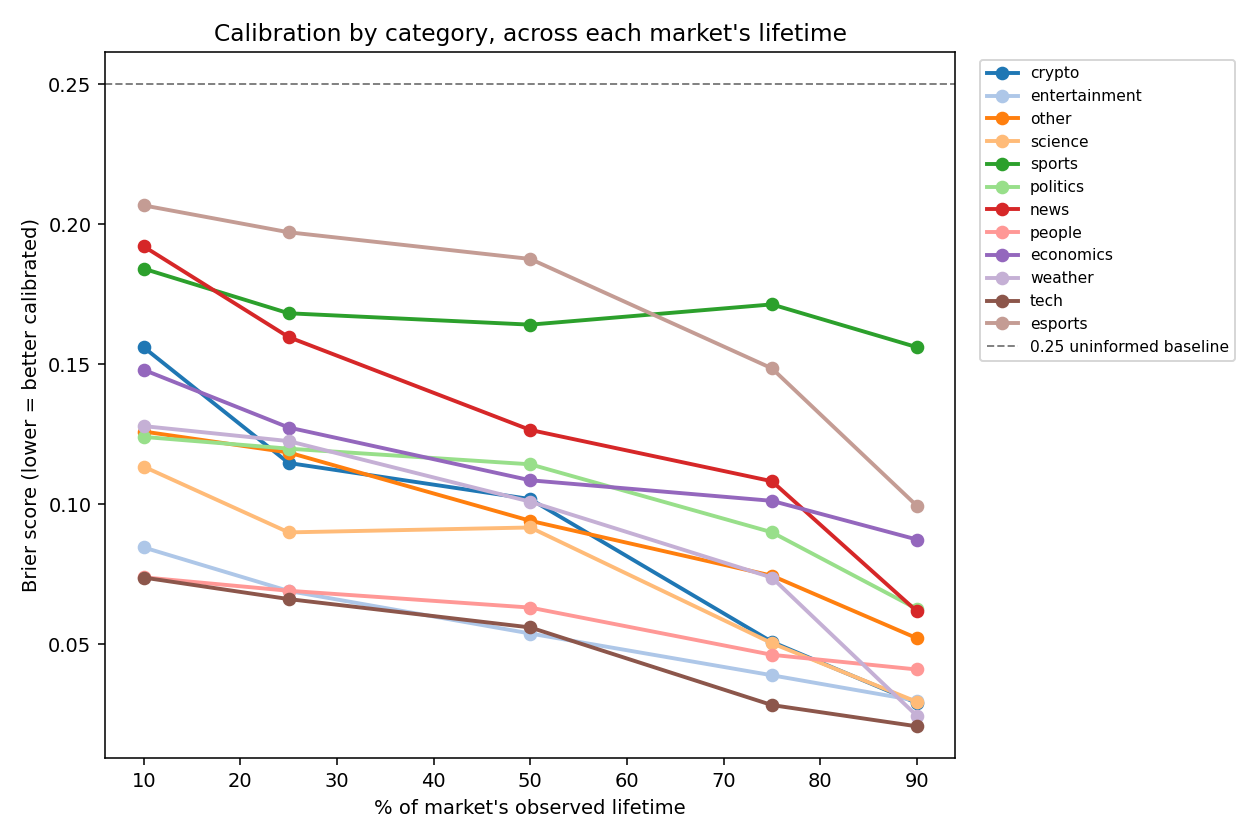

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
plottable = [c for c in CATEGORIES if all(summary[c][f] is not None for f in CHECKPOINTS)]
colors = plt.cm.tab20(range(len(plottable)))
for i, cat in enumerate(plottable):
    ys = [summary[cat][f] for f in CHECKPOINTS]
    xs = [int(f * 100) for f in CHECKPOINTS]
    ax.plot(xs, ys, marker="o", label=cat, color=colors[i], linewidth=2)
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="0.25 uninformed baseline")
ax.set_xlabel("% of market's observed lifetime")
ax.set_ylabel("Brier score (lower = better calibrated)")
ax.set_title("Calibration by category, across each market's lifetime")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()


most categories converge toward the bottom-left as they approach
resolution — real information is arriving and prices are using it. `sports` (green) and
`esports` (tan) are the visible exceptions: they stay elevated almost the entire way,
`sports` barely leaving the 0.15-0.18 band even at 90% of its lifetime. That's a genuinely
different market-behavior pattern, not just "sports is noisier at every point" — it's
specifically "sports doesn't resolve its own uncertainty over time the way other categories
do." A plausible read: sports outcomes swing on events (injuries, in-game momentum) that can
happen literally up to the final whistle, unlike e.g. a crypto threshold market where the
underlying price process is continuously observable and increasingly informative as the
deadline nears.

## Chart 2 — Mid-life calibration, ranked (comparable to the earlier single-checkpoint pass)

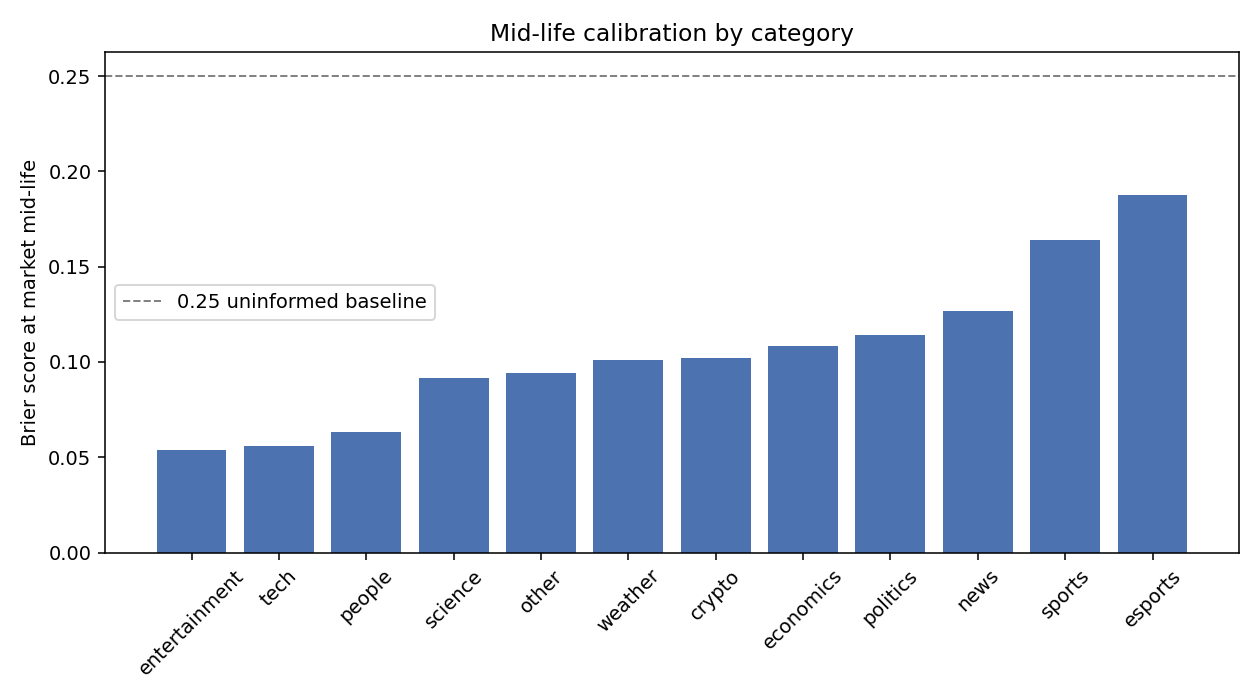

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
vals = sorted(
    [(cat, summary[cat][0.5]) for cat in CATEGORIES if summary[cat][0.5] is not None],
    key=lambda x: x[1]
)
ax.bar([v[0] for v in vals], [v[1] for v in vals], color="#4C72B0")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=1, label="0.25 uninformed baseline")
ax.set_ylabel("Brier score at market mid-life")
ax.set_title("Mid-life calibration by category")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
plt.show()


the same ranking as the original single-checkpoint pass —
entertainment/tech/people best, sports/esports worst — confirming that finding wasn't an
artifact of picking one arbitrary checkpoint. It holds up at every checkpoint we tested.

## Chart 3 — Which categories actually sharpen up, and which don't

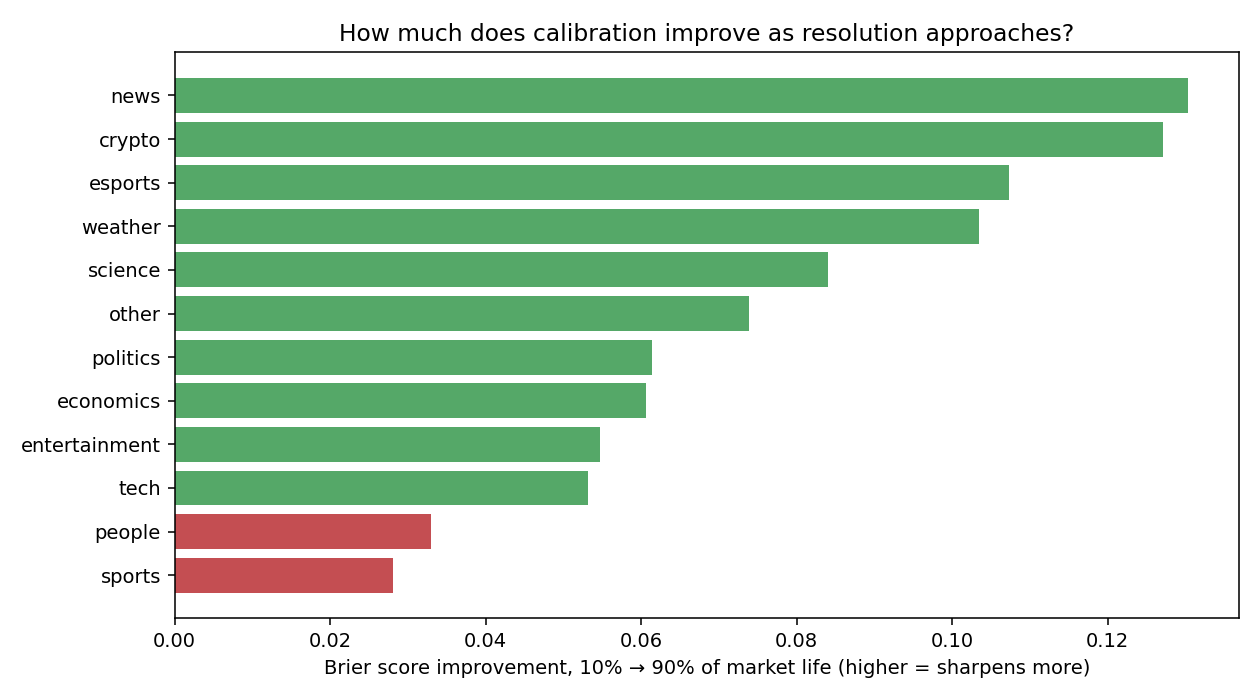

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
imp = sorted(
    [(cat, summary[cat][0.1] - summary[cat][0.9]) for cat in plottable],
    key=lambda x: x[1]
)
colors_i = ["#C44E52" if v < 0.05 else "#55A868" for _, v in imp]
ax.barh([c for c, _ in imp], [v for _, v in imp], color=colors_i)
ax.set_xlabel("Brier score improvement, 10% \u2192 90% of market life (higher = sharpens more)")
ax.set_title("How much does calibration improve as resolution approaches?")
fig.tight_layout()
plt.show()


`news` and
`crypto` sharpen the most (>0.12 improvement) as their markets approach resolution.
`sports` and `people` (red bars) barely improve at all — under 0.035. Combined with Chart 2,
`sports` is both poorly calibrated *and* doesn't get meaningfully better with time, while a
category like `crypto` starts rough (0.156) but ends up one of the best-calibrated by 90%
(0.029) — most of its apparent "randomness" resolves late, not early.

## Methodology limits — read before citing this anywhere

- **Sample, not census.** Up to 300 randomly sampled files per category (fixed seed 42),
  not every file. `esports` (29 resolved used) and `news` (76 total files in the whole local
  dataset) are thin samples — treat those two rows as lower-confidence than the rest.
- **Resolved-outcome inference, not ground truth.** "Resolved" here means the market's last
  recorded price was within 0.02 of 0 or 1. That's a reasonable proxy, not the actual
  on-chain resolution record. Some fraction of borderline markets get dropped rather than
  mis-classified — that's the intended tradeoff, but it means the resolved-market pool isn't
  a random sample of *all* markets in a category, only the ones that ended up clearly settled
  by the time this data was pulled.
- **Checkpoint timing is relative, not absolute.** "50% of lifetime" means 50% of the way
  between a market's first and last *recorded* timestamp in this dataset, not 50% of its
  official scheduled duration. Two markets with very different real durations both get
  treated as directly comparable at "50%," which is a simplification.

## Summary

Three real findings from this pass, all reproducible from the code above:

1. **Calibration is domain-specific**, confirmed directly from data rather than cited from
   someone else's paper: a >3x gap between the best-calibrated categories (entertainment,
   tech, people) and the worst (sports, esports), consistent at every lifetime checkpoint
   tested.
2. **Categories don't just differ in calibration level, they differ in calibration
   *dynamics*.** Crypto starts noisy and ends sharp. Sports stays noisy the whole way. A
   single-point Brier score can't distinguish these two very different behaviors, which is
   the whole reason this multi-checkpoint version exists.
3. **The finding survives the more rigorous version.** The ranking from the original
   single-checkpoint pass held up across all five checkpoints, not just the one that was
   originally checked.


## Practical takeaways

Stripped of methodology, what this actually means if you're using Polymarket prices as a
probability estimate:

- **Tech, entertainment, and people markets are genuinely trustworthy, even early.** Brier
  scores of 0.05-0.07 by mid-life — a price from these categories doesn't need much
  discounting.
- **Sports and esports prices are the least trustworthy, and waiting doesn't fix it.**
  Sports barely moves across a market's entire life (0.184 → 0.156). Don't assume "closer to
  the game = sharper price" here the way it's reasonable to assume elsewhere — the market
  isn't resolving its own uncertainty over time in this category.
- **Crypto and news are the opposite pattern: rough early, sharp late.** 0.156 → 0.029 for
  crypto, 0.192 → 0.062 for news. An early-life price in these categories is meaningfully
  less informative than a late-life one — weight recent price much more than an early
  snapshot.
- **The one-line version**: "prediction market prices are calibrated" is a fact about a
  category at a specific point in its life, not a fact about the platform. Treat it that
  way.
- **Confidence caveat**: `esports` (29 resolved markets) and `news` (76 files total) are
  thin samples — weight those two conclusions less than sports/crypto/tech, which rest on
  much larger samples.